In [78]:
# import matplotlib.pyplot as plt
# import numpy as np
# from astropy.io import fits
# from astropy.table import Table
# from astropy.nddata import extract_array
# from astropy.coordinates import SkyCoord
# from astropy.wcs import WCS
# from astropy.wcs.utils import skycoord_to_pixel
# from reproject import reproject_interp
# from astropy.visualization import make_lupton_rgb
# from astropy.wcs import utils
# import matplotlib.patches as mpatches
# from matplotlib.patches import Rectangle
# from matplotlib.patches import Circle
# from matplotlib.patches import ConnectionPatch

# from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# from astropy.visualization.wcsaxes import WCSAxes
# import astropy.units as u


# path = '/Users/sophiakressy/Desktop/Snazzy_AR_Proposal_figure/1996cr_jhatted/'
# miri770 = 'jw04225-o001_t001_miri_f770w_jhat.fits'
# miri1000 = 'jw04225-o001_t001_miri_f1000w_jhat.fits'
# miri1130 = 'jw04225-o001_t001_miri_f1130w_jhat.fits'
# miri_files = [path+miri770,path+miri1130,path+miri1130] #,path+"North_f2100w.fits"]

# target_name = 'SN1996cr'
# target_ra = 213.2917505 
# target_dec = -65.3457024
# ref_img_name = '/Users/sophiakressy/Desktop/Snazzy_AR_Proposal_figure/1996cr_jhatted/jw04225-o001_t001_miri_f770w_jhat.fits'
# instrument_name = 'MIRI'


# # Open all fits images
# miri770_hdu  = fits.open(miri_files[0])
# miri1000_hdu = fits.open(miri_files[1])
# miri1130_hdu = fits.open(miri_files[2])
# # miri2100_hdu = fits.open(miri_files[3])

# miri_770_data_r    = miri770_hdu[1].data
# miri_1000_data_r   = miri1000_hdu[1].data
# miri_1130_data_r   = miri1130_hdu[1].data
# # miri_2100_data_r   = miri2100_hdu[1].data

# miri_770_header = miri770_hdu[1].header

# wcs_770  = WCS(miri770_hdu[1].header)
# wcs_1000 = WCS(miri1000_hdu[1].header)
# wcs_1130 = WCS(miri1130_hdu[1].header)
# # wcs_2100 = WCS(miri2100_hdu[1].header)

# # Handle Nans; set Nans to 0
# miri_770_data_r[np.isnan(miri_770_data_r)] = 0
# miri_1000_data_r[np.isnan(miri_1000_data_r)] = 0
# miri_1130_data_r[np.isnan(miri_1130_data_r)] = 0
# # miri_2100_data_r[np.isnan(miri_2100_data_r)] = 0

# # How to handle negative values? Not sure. Going to set to 0
# miri_770_data_r[miri_770_data_r<0] = 0.01
# miri_1000_data_r[miri_1000_data_r<0] = 0.01
# miri_1130_data_r[miri_1130_data_r<0] = 0.01
# # miri_2100_data_r[miri_2100_data_r<0] = 0.01



# # Convert FK4 to FK5
# wcs_fk5 = wcs_770.deepcopy()
# wcs_fk5.wcs.equinox = 2000.0
# wcs_fk5.wcs.ctype = ['RA---TAN', 'DEC--TAN']
# wcs_fk5.wcs.radesys = 'ICRS'

# print(wcs_fk5.wcs.radesys)  # Should output 'ICRS' or 'FK5'
# print(wcs_fk5.wcs.equinox)  # Should be 2000.0


# # Image pixel location of SN 83V taken from DS9
# x = int(970.80233)
# y = int(985.25728)

# # Crop image with indexing to focus on SN -- for cropping, [y,x]
# window = 100
# y0 = y-window
# y1 = y+window
# x0 = x-window
# x1 = x+window

# # Crop region (same as before)
# crop_small = (slice(y0, y1), slice(x0, x1))

# # Set figure space
# fig = plt.figure(figsize=(5,5))
# ax = plt.subplot(projection = wcs_fk5)

# # plot image in log space
# miri770 = ax.imshow(miri_770_data_r[crop_small], norm='log')

# # axis labels and params
# ax.set_ylabel('Right Ascension', fontsize = 12)
# ax.set_xlabel('Declination', fontsize =12)
# plt.show()


# # Reproject other images onto the reference WCS
# miri_1000_reproj, _ = reproject_interp((miri_1000_data_r, miri1000_hdu[1].header), wcs_fk5)
# miri_1130_reproj, _ = reproject_interp((miri_1130_data_r, miri1130_hdu[1].header), wcs_fk5)
# # miri_2100_reproj, _ = reproject_interp((miri_2100_data_r, miri2100_hdu[0].header), wcs_fk5)


# # plot MIRI image overlay in all filters
# fig = plt.figure(figsize=(8, 8))
# ax = plt.subplot(projection=wcs_770)

# inorm0 = 'log'

# # Overlay images with transparency and different colormaps
# # ax.imshow(miri_2100_reproj[crop_small], norm=inorm0, cmap='Reds', alpha=0.7, vmin=ivmin0, vmax=ivmax0)
# ax.imshow(miri_1130_reproj[crop_small], norm=inorm0, cmap='Reds', alpha=0.6)
# ax.imshow(miri_1000_reproj[crop_small], norm=inorm0, cmap='Greens', alpha=0.5)
# base = ax.imshow(miri_770_data_r[crop_small], norm=inorm0, cmap='Blues', alpha=0.4)

# ax.set_ylabel('Right Ascension', fontsize=12)
# ax.set_xlabel('Declination', fontsize=12)
# plt.title('JWST MIRI Overlaid Images')
# plt.show()


## Working with ChatGPT to make a better version of above

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
from astropy.io import fits
# from astropy.table import Table
# from astropy.nddata import extract_array
# from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
# from astropy.wcs.utils import skycoord_to_pixel
from reproject import reproject_interp
# from astropy.visualization import make_lupton_rgb
# from astropy.wcs import utils
# import matplotlib.patches as mpatches
# from matplotlib.patches import Rectangle
# from matplotlib.patches import Circle
# from matplotlib.patches import ConnectionPatch

# from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# from astropy.visualization.wcsaxes import WCSAxes
# import astropy.units as u

In [53]:
def orient_north(input_fits_path, output_fits_path, pad_factor):
    # Load FITS
    with fits.open(input_fits_path) as hdu:
        # hdu = hdul[0]
        data = hdu[1].data
        # header = hdu.header
        wcs = WCS(hdu[1].header)
        data[np.isnan(data)] = 0
        data[data<0] = 0.01

        # Get original shape
        ny, nx = data.shape

        # New shape with padding
        pad_nx = int(nx * pad_factor)
        pad_ny = int(ny * pad_factor)

        # Create new WCS header for North-up orientation
        header_north = wcs.deepcopy().to_header()

        # Force PC matrix to identity (North-up)
        header_north['PC1_1'] = 1
        header_north['PC1_2'] = 0
        header_north['PC2_1'] = 0
        header_north['PC2_2'] = 1

        # Adjust reference pixel to be in the center of the new image
        header_north['NAXIS1'] = pad_nx
        header_north['NAXIS2'] = pad_ny
        header_north['CRPIX1'] = pad_nx / 2
        header_north['CRPIX2'] = pad_ny / 2

        wcs_north = WCS(header_north)

        # Reproject
        reprojected_data, _ = reproject_interp((data, wcs), wcs_north, shape_out=(pad_ny, pad_nx))

        # Save output
        fits.writeto(output_fits_path, reprojected_data, wcs_north.to_header(), overwrite=True)
        
    return reprojected_data

In [61]:
path = '/Users/sophiakressy/Desktop/Snazzy_AR_Proposal_figure/1996cr_jhatted/'
miri770 = path + 'jw04225-o001_t001_miri_f770w_jhat.fits'
miri1000 = path + 'jw04225-o001_t001_miri_f1000w_jhat.fits'
miri1130 = path + 'jw04225-o001_t001_miri_f1130w_jhat.fits'

miri_files = [miri770, miri1000, miri1130]
# nir_files = [path+nir1, path+nir2,path+nir3, path+nir4]
mtitles = ['f770w.fits','f1000w.fits','f1130w.fits',"f2100w.fits"]
# ntitles = ['f200w','f300m','f335m',"f360m"]

for i in range(len(miri_files)):
    orient_north(miri_files[i], path+'North_'+mtitles[i], pad_factor=2.0)
# for nfile in range(len(nir_files)):
#     orient_north(nir_files[nfile],npath+'North_'+ntitles[nfile],pad_factor=2.0)

Set OBSGEO-B to   -36.162920 from OBSGEO-[XYZ].
Set OBSGEO-H to 1731158023.314 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -36.162920 from OBSGEO-[XYZ].
Set OBSGEO-H to 1731158023.314 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -36.162920 from OBSGEO-[XYZ].
Set OBSGEO-H to 1731158023.314 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -36.162920 from OBSGEO-[XYZ].
Set OBSGEO-H to 1731158023.314 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Set OBSGEO-B to   -36.162920 from OBSGEO-[XYZ].
Set OBSGEO-H to 1731158023.314 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


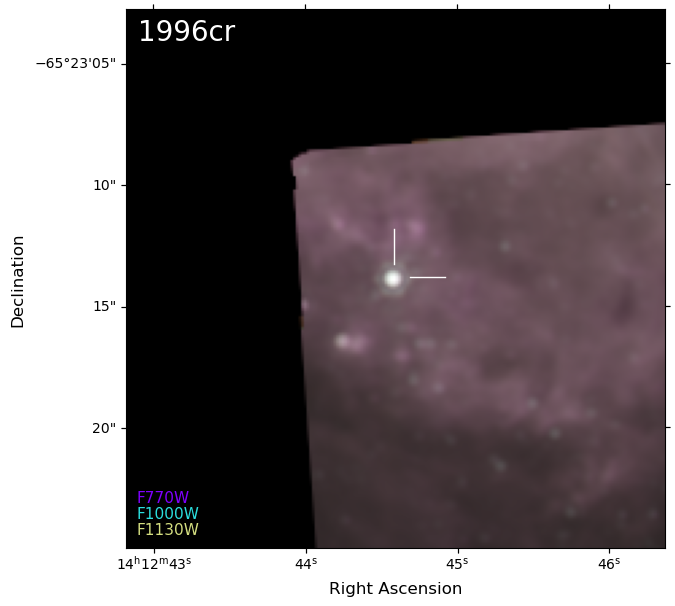

In [77]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp
from astropy.visualization import AsinhStretch

# Paths
path = '/Users/sophiakressy/Desktop/Snazzy_AR_Proposal_figure/1996cr_jhatted/'
miri770 = path + 'North_f770w.fits'
miri1000 = path + 'North_f1000w.fits'
miri1130 = path + 'North_f1130w.fits'

# Open data
with fits.open(miri770) as hdu1, fits.open(miri1000) as hdu2, fits.open(miri1130) as hdu3:
    data_770 = hdu1[0].data
    data_1000 = hdu2[0].data
    data_1130 = hdu3[0].data
    wcs_ref = WCS(hdu1[0].header)

# Handle NaNs and negatives
for arr in [data_770, data_1000, data_1130]:
    arr[np.isnan(arr)] = 0
    arr[arr < 0] = 0

# Reproject to reference WCS (F770W)
data_1000_reproj, _ = reproject_interp((data_1000, WCS(hdu2[0].header)), wcs_ref)
data_1130_reproj, _ = reproject_interp((data_1130, WCS(hdu3[0].header)), wcs_ref)

# Crop region
x, y, window = int(1533.5138), int(1447.3484), 100
crop = (slice(y - window, y + window), slice(x - window, x + window))
f770 = data_770[crop]
f1000 = data_1000_reproj[crop]
f1130 = data_1130_reproj[crop]

# Normalize each to similar scale
def norm(arr):
    return arr / np.nanpercentile(arr, 99.5)

f770_n = norm(f770)
f1000_n = norm(f1000)
f1130_n = norm(f1130)

# --- RGB weights ---
weights = {
    'F770W':  (0.50, 0.00, 1.00),
    'F1000W': (0.17, 0.87, 0.87),
    'F1130W': (0.83, 0.87, 0.5),
}

# Combine into RGB channels
R = (weights['F770W'][0] * f770_n +
     weights['F1000W'][0] * f1000_n +
     weights['F1130W'][0] * f1130_n)
G = (weights['F770W'][1] * f770_n +
     weights['F1000W'][1] * f1000_n +
     weights['F1130W'][1] * f1130_n)
B = (weights['F770W'][2] * f770_n +
     weights['F1000W'][2] * f1000_n +
     weights['F1130W'][2] * f1130_n)

# Apply stretch
stretch = AsinhStretch(0.02)
R = stretch(R / np.nanmax(R))
G = stretch(G / np.nanmax(G))
B = stretch(B / np.nanmax(B))

# Stack RGB
rgb = np.dstack([R, G, B])
rgb = np.clip(rgb, 0, 1)

# --- Plot ---
fig = plt.figure(figsize=(7,7))
ax = plt.subplot(projection=wcs_ref)
ax.imshow(np.fliplr(rgb), origin='lower')
ax.set_xlabel('Right Ascension', fontsize=12)
ax.set_ylabel('Declination', fontsize=12)

# --- Add stacked bottom-left labels ---
labels = ['F1130W', 'F1000W', 'F770W']  # reversed order (blue → red)
y_start = 0.02      # bottom offset
y_step = 0.03       # vertical spacing between labels

for i, filt in enumerate(labels):
    color = weights[filt]
    ax.text(
        0.02, y_start + i * y_step, filt,
        color=color,
        transform=ax.transAxes,
        fontsize=11,
        ha='left', va='bottom',
    )
#fontweight='bold'

hx_line = [(window)+5, (window)+18]
hy_line = [(window), (window)]

vx_line = [(window-1), (window-1)]
vy_line = [(window)+5, (window)+18]

ax.plot(hx_line, hy_line, color='white', linewidth=1, linestyle='-')
ax.plot(vx_line, vy_line, color='white', linewidth=1, linestyle='-')

ax.text(4, window*2-12, '1996cr', fontsize=20, color = 'white')

# plt.show()
plt.savefig('/Users/sophiakressy/Desktop/Snazzy_AR_Proposal_figure/1996cr.pdf')
